# Luis — Part A (Team A)

Working notebook for Project 2 so edits don’t conflict with teammates.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

In [3]:
print('hello from luis')

hello from luis


In [4]:
df = pd.read_csv("economy-and-growth.csv")
df.head()

,Country Name,Country Code,Year,average_value_DEC alternative conversion factor (LCU per US$),average_value_Discrepancy in expenditure estimate of GDP (current LCU),average_value_GDP (constant 2010 US$),average_value_GDP (constant LCU),average_value_GDP (current LCU),average_value_GDP (current US$),average_value_GDP deflator (base year varies by country),...,average_value_Net primary income (Net income from abroad) (current LCU),average_value_Net primary income (Net income from abroad) (current US$),average_value_Net secondary income (Net current transfers from abroad) (current LCU),average_value_Net secondary income (Net current transfers from abroad) (current US$),"average_value_PPP conversion factor, GDP (LCU per international $)","average_value_PPP conversion factor, private consumption (LCU per international $)",average_value_Price level ratio of PPP conversion factor (GDP) to market exchange rate,average_value_Taxes less subsidies on products (constant LCU),average_value_Taxes less subsidies on products (current LCU),average_value_Taxes less subsidies on products (current US$)
0,Arab World,ARB,1988,NaN,NaN,8.222111e+11,NaN,NaN,4.219210e+11,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,United Arab Emirates,ARE,1966,4.7619,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Antigua and Barbuda,ATG,1962,1.7143,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Antigua and Barbuda,ATG,1971,1.9749,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Burundi,BDI,2008,1185.6908,461000.0,1.862084e+09,1.381681e+12,1.911139e+12,1.611836e+09,138.319844,...,-5.098471e+09,-4.300000e+06,3.904480e+11,3.293000e+08,369.595027,401.714996,0.311713,1.161580e+11,1.578320e+11,1.331140e+08


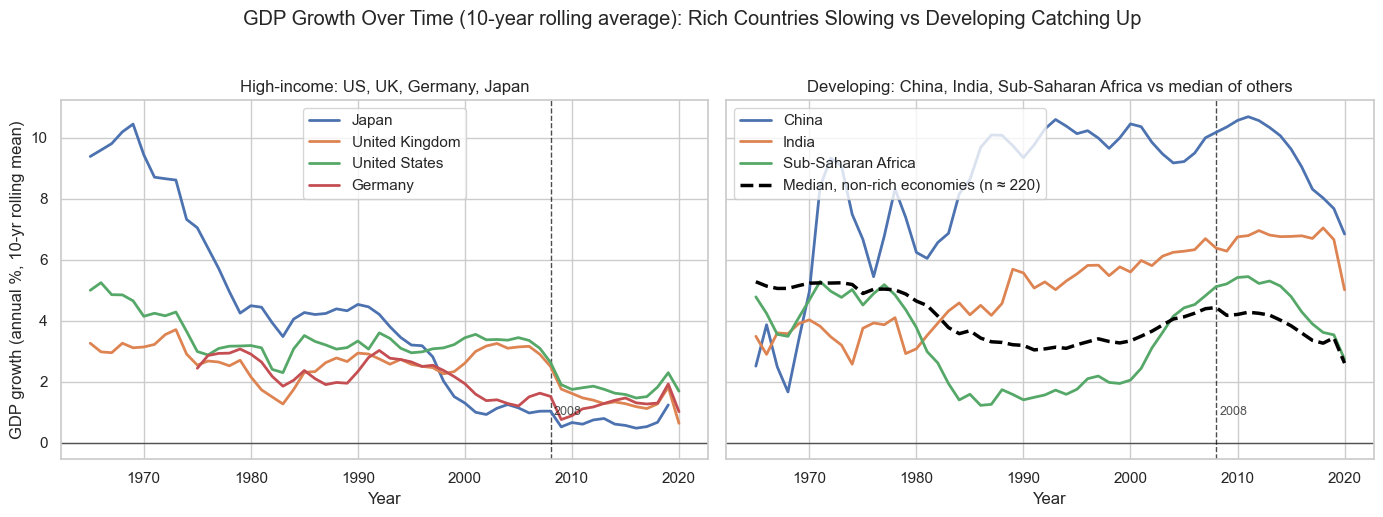

In [6]:
# cols needed — keep Country Code so we can add a median-of-non-rich benchmark line
growth_col = "average_value_GDP growth (annual %)"
if "Country Code" not in df.columns:
    df = pd.read_csv("economy-and-growth.csv")

df = df[["Country Name", "Country Code", "Year", growth_col]].copy()
# Clean types (Year -> int, growth -> numeric) and drop missing
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df[growth_col] = pd.to_numeric(df[growth_col], errors="coerce")
df = df.dropna(subset=["Year", growth_col])
df["Year"] = df["Year"].astype(int)

# Choose countries
rich = ["United States", "United Kingdom", "Germany", "Japan"]
developing_base = ["China", "India"]
# Optional: include one Sub-Saharan Africa aggregate IF it exists in your data
ssa_candidates = [
    "Sub-Saharan Africa",
    "Sub-Saharan Africa (excluding high income)",
    "Sub-Saharan Africa (IDA & IBRD countries)",
]
ssa_present = [x for x in ssa_candidates if x in set(df["Country Name"].unique())]
developing = developing_base + (ssa_present[:1] if ssa_present else [])

window = 10  # 10-year smoothing
min_pr = window // 2

# --- Median GDP growth across non-rich economies (country rows only; drops WB aggregates) ---
BAD_NAME_FRAGMENTS = (
    "World",
    "income",
    "only ",
    "IDA &",
    "IBRD",
    "OECD",
    "Euro area",
    "Pacific island",
    "North America",
    "Fragile",
    "Small states",
    "Arab World",
    "Caribbean small",
    "Central Europe",
    "European Union",
    "Latin America",
    "Sub-Saharan Africa",
    "South Asia",
    "East Asia & Pacific",
    "Middle East & North Africa",
    "Europe & Central Asia",
)
code_ok = df["Country Code"].astype(str).str.match(r"^[A-Z]{3}$", na=False)


def _name_is_aggregate(name: str) -> bool:
    n = str(name)
    return any(frag in n for frag in BAD_NAME_FRAGMENTS)


non_rich_country = df[
    code_ok & ~df["Country Name"].map(_name_is_aggregate) & ~df["Country Name"].isin(rich)
].copy()
n_economies = non_rich_country["Country Name"].nunique()
median_by_year = (
    non_rich_country.groupby("Year", as_index=False)[growth_col]
    .median()
    .sort_values("Year")
)
median_by_year["growth_smooth"] = median_by_year[growth_col].rolling(
    window, min_periods=min_pr
).mean()
median_by_year = median_by_year[median_by_year["Year"] >= 1960]

# Filter to plotted country lines
plot_df = df[df["Country Name"].isin(rich + developing)].copy()
plot_df = plot_df.sort_values(["Country Name", "Year"])
plot_df["growth_smooth"] = (
    plot_df.groupby("Country Name")[growth_col]
    .transform(lambda s: s.rolling(window, min_periods=min_pr).mean())
)
plot_df = plot_df[plot_df["Year"] >= 1960]

# Plot: two panels with shared y-axis
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax in axes:
    ax.axvline(2008, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax.text(2008 + 0.3, ax.get_ylim()[1] * 0.9, "2008", fontsize=9, alpha=0.8)

# Panel 1: rich countries
sub1 = plot_df[plot_df["Country Name"].isin(rich)].sort_values("Year")
sns.lineplot(data=sub1, x="Year", y="growth_smooth", hue="Country Name", ax=axes[0], linewidth=2)
axes[0].axhline(0, color="black", linewidth=1, alpha=0.6)
axes[0].set_title("High-income: US, UK, Germany, Japan")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("GDP growth (annual %, 10-yr rolling mean)")

# Panel 2: developing + median benchmark
sub2 = plot_df[plot_df["Country Name"].isin(developing)].sort_values("Year")
sns.lineplot(data=sub2, x="Year", y="growth_smooth", hue="Country Name", ax=axes[1], linewidth=2)
axes[1].plot(
    median_by_year["Year"],
    median_by_year["growth_smooth"],
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Median, non-rich economies (n ≈ {n_economies})",
    zorder=10,
)
axes[1].axhline(0, color="black", linewidth=1, alpha=0.6)
axes[1].set_title(
    "Developing: China, India"
    + (f", {ssa_present[0]}" if ssa_present else "")
    + " vs median of others"
)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("")

h2, lab2 = axes[1].get_legend_handles_labels()
axes[1].legend(h2, lab2, title="", frameon=True)

# Cosmetics
fig.suptitle(
    "GDP Growth Over Time (10-year rolling average): Rich Countries Slowing vs Developing Catching Up",
    y=1.03,
)
axes[0].legend(title="", frameon=True)
plt.tight_layout()
# Save for index.html (same folder as repo root / open index.html locally)
plt.savefig("viz_for_linechart.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()